In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import texplot

import freealg
from freealg import AlgebraicForm
from freealg.distributions import DeformedMarchenkoPastur
from freealg.visualization import plot_flow, plot_mass, ridgeplot

plot_dir = './plots'

In [2]:
config1 = dict(
    input_filename = 'deformed_mp_eigs.npz',
    deg_m = 3,
    # effective_n = 80_000,
    xlim = (0.5, 8),
    ylim = (2.55, 2.55, 0.52),
    nbins = (80, 120),
    label_mode = 'pow-int',
    save_filename = 'deformed-mp',
)

# -------

config = config1

[(1.005518159668944, 3.1256892314391456), (4.16272377987857, 7.595354543299054)]


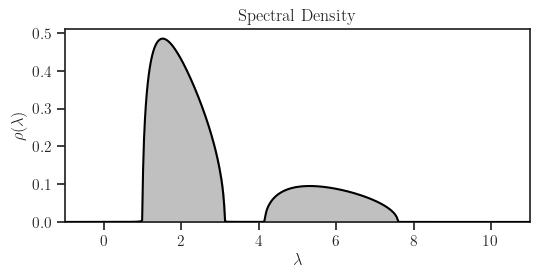

In [3]:
filename = 'deformed_mp'
title = 'Deformed Marchenko-Pastur'

lam = 0.1
t1 = 2.0
t2 = 5.5
w1 = 0.75

dist = DeformedMarchenkoPastur(t=[t1, t2], w=[w1, 1-w1], c=lam)

# Support
support = dist.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 1.0)
x_max = numpy.ceil(max(b for a, b in support) + 1.0)
y_min, y_max = -3.0, 3.0

_ = dist.density(plot=True, latex=True, save=False)

In [4]:
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, config['input_filename']), allow_pickle=True)
out = data['out'].item()

sizes = out['sizes']
eigs = out['eigs']
wall_times = out['wall_times']
proc_times = out['proc_times']
n, p = out['shape']

for i in range(sizes.size):
    print(f'{i:>2d}: {sizes[i]:>6d}')

 0:   1000
 1:   2000
 2:   4000
 3:   8000
 4:  16000
 5:  32000


fit residual max  : 4.7555e-03
fit residual 99.9%: 3.2734e-03

Coefficients (real)
+0.82107322 -2.71904045 +1.81213128 +0.01577256 
-0.17892678 +1.50135495 -1.22783682 -0.02218107 
+0.00000000 -0.17892707 +0.16213056 +0.00531625 

Coefficients (imag) norm: 0.0000e+00

	frac_bad: 0.922
	n_bad   : 118
	n_test  : 128

Support:
[(1.809214809359739, 2.192804060020593), (5.153436249768195, 5.828042421602667)]

Atoms:
[]


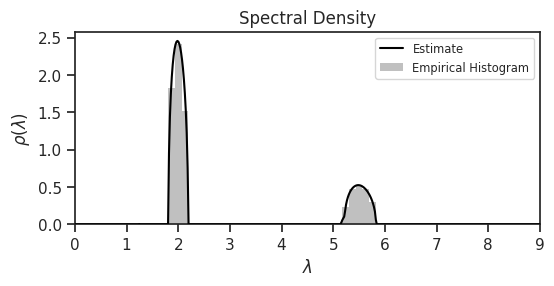

mass: 1.000512


In [5]:
start_idx = 0
ratio = dist.ratio * (sizes[start_idx] / sizes[-1])
af = AlgebraicForm(eigs[start_idx], ratio=ratio, delta=1e-5)

deg_m = config['deg_m']
deg_z = 2

coeffs = af.fit(
    deg_m, deg_z, reg=0, normalize=True, triangular=None,
    mu='auto', mu_reg=0, verbose=True)

print('\nSupport:')
est_supp = af.support()
print(est_supp)

print('\nAtoms:')
print(af.atoms())

# x_min, x_max = config['xlim']
x = numpy.linspace(x_min, x_max, 500)
rho = af.density(x, plot=True, latex=False)

mass = numpy.trapz(rho, x)
print('mass: %f' % mass)

success rate per t: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


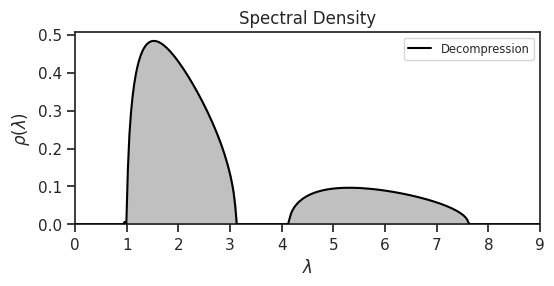

In [6]:
end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]

x = numpy.linspace(x_min, x_max, 300)

newton_opt = dict(
    dt_max=0.02,
    sweep_pad=50,
)

rho, x = af.deform(
    fd_sizes, x=x, method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=False,
    atom_eps=0,
    verbose=True, plot=True, latex=False)

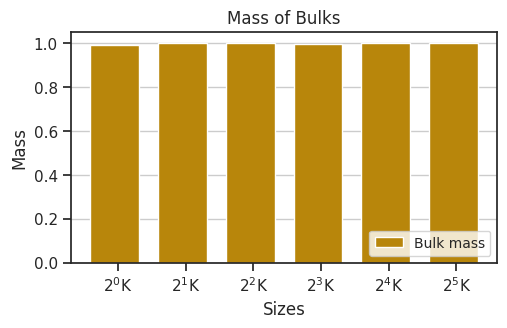

In [7]:
plot_mass(fd_sizes, x, rho, atoms=None, log_x=True, gap=0.7, save=False)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/deformed-mp-flow.pdf".


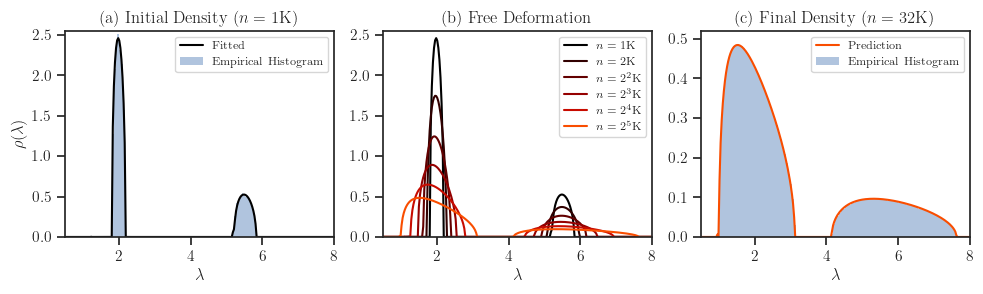

In [9]:
plot_flow(fd_sizes, x, rho, eigs[start_idx], eigs[end_idx], xlim=config['xlim'],
          ylim=config['ylim'], share_ax=False, layout='horizontal', title='Free Deformation',
          cmap=plt.cm.gist_heat,
          c_range=(0.0, 0.65),
          hist_color='lightsteelblue',
          nbins=config['nbins'],
          label_mode=config['label_mode'],
          save=join(plot_dir, config['save_filename'] + '-flow.pdf'),
          latex=True)

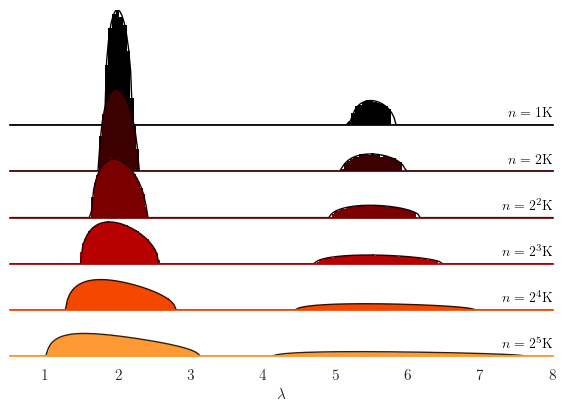

In [11]:
ridgeplot(fd_sizes, x, rho, eigs, text_side='right', hspace=-0.6, scaley=False,
          xlim=config['xlim'],
          label_mode=config['label_mode'],
          save=False,
          # save=join(plot_dir, config['save_filename'] + '-ridge.pdf'))
          latex=True)